# Data augmentation with `tv.augment`

Augmentation makes more training images from the ones you have: mirrored,
rotated, zoomed, recoloured, blurred. A transform takes and returns
`(image, annotations)`, so boxes and pitch keypoints move with the pixels and
the labels stay correct.

* Geometric transforms (`HorizontalFlip`, `RandomAffine`) move pixels, boxes
  and keypoints together.
* Photometric transforms (`ColorJitter`, `GaussianBlur`, `MotionBlur`,
  `GaussianNoise`, `JpegCompression`) change pixel values only.
* `Compose` and `OneOf` combine them; `augment_dataset` writes augmented
  copies of a training split to disk.

There is no vertical flip on purpose: broadcast footage is never upside down.

Part of the [TactiFoot Vision notebooks](README.md); datasets are introduced
in [01_data](01_data.ipynb).

In [1]:
import os
from dataclasses import replace
from pathlib import Path

import numpy as np

import tactifoot_vision as tv
from tactifoot_vision import augment as A

# The repository root, found by walking up from the working directory and kept
# relative, so printed paths do not depend on where the repository lives.
_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file()
)
ROOT = Path(os.path.relpath(_root))
DATA, MODELS = ROOT / "data", ROOT / "models"
OUT = ROOT / "outputs" / "notebooks" / "02_augmentation"
VIDEO = DATA / "videos" / "broadcast_60s.mp4"

tv.setup_logging("WARNING")
# Most figures are video frames: JPEG keeps the saved notebook small.
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 85}}

detection = tv.load_dataset(DATA / "datasets" / "football_yolo").subset(
    {"train": 60, "valid": 20}, seed=0
)
pitch_data = tv.load_dataset(DATA / "keypoints")
image, labels = detection.read("train", 3)
pitch_image, pitch_labels = pitch_data.read("train", 4)
print(detection)
print(pitch_data)

Dataset(name='football_yolo', task=detect, classes=['ball', 'goalkeeper', 'player', 'referee'], train=60, valid=20)
Dataset(name='keypoints', task=pose, classes=['pitch'], keypoints=32, train=255, valid=34, test=28)


Every transform has a probability `p` of being applied. Calls take a seeded
`np.random.Generator`, so a result can be reproduced. A small helper draws
the labels before and after with `tv.viz.draw_annotations`.

In [2]:
def before_after(transform, image, labels, class_names, seeds=(0,), width=12):
    images = [tv.viz.draw_annotations(image, labels, class_names)]
    titles = [f"original: {len(labels)} objects"]
    for seed in seeds:
        new_image, new_labels = transform(image, labels, np.random.default_rng(seed))
        images.append(tv.viz.draw_annotations(new_image, new_labels, class_names))
        titles.append(
            f"{type(transform).__name__} (seed {seed}): {len(new_labels)} objects"
        )
    return tv.show(images, titles, cols=min(len(images), 3), width=width)

## Geometric transforms

`HorizontalFlip` mirrors the image and its boxes. `p=1.0` forces it here; in
training a flip on half the images (the default `p=0.5`) is typical.

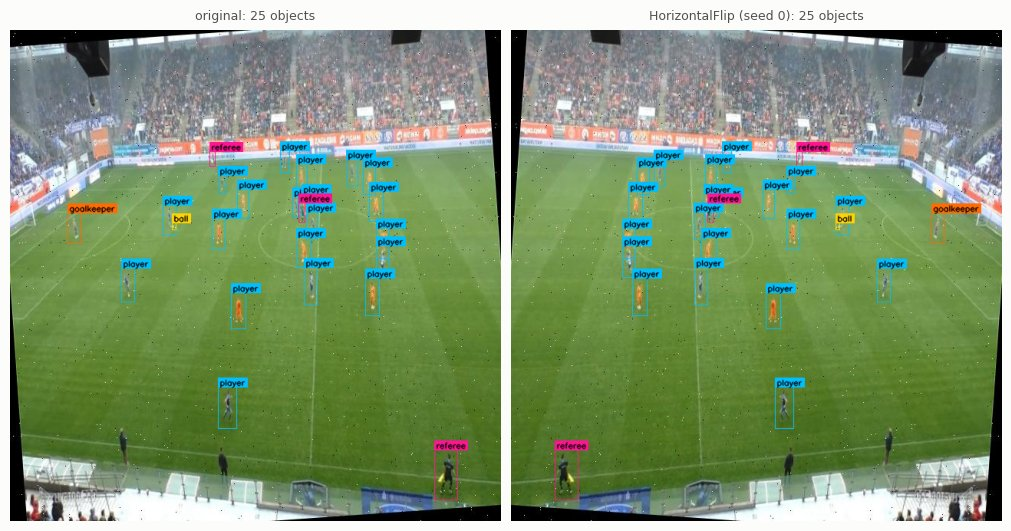

In [3]:
before_after(A.HorizontalFlip(p=1.0), image, labels, detection.class_names, width=10)

`RandomAffine` rotates and scales about the image centre, then shifts. Each
box becomes the bounding box of its four moved corners, clipped to the image.
Objects pushed mostly out of frame (less than `min_area_ratio` of the box
left) are dropped, so the object count can shrink.

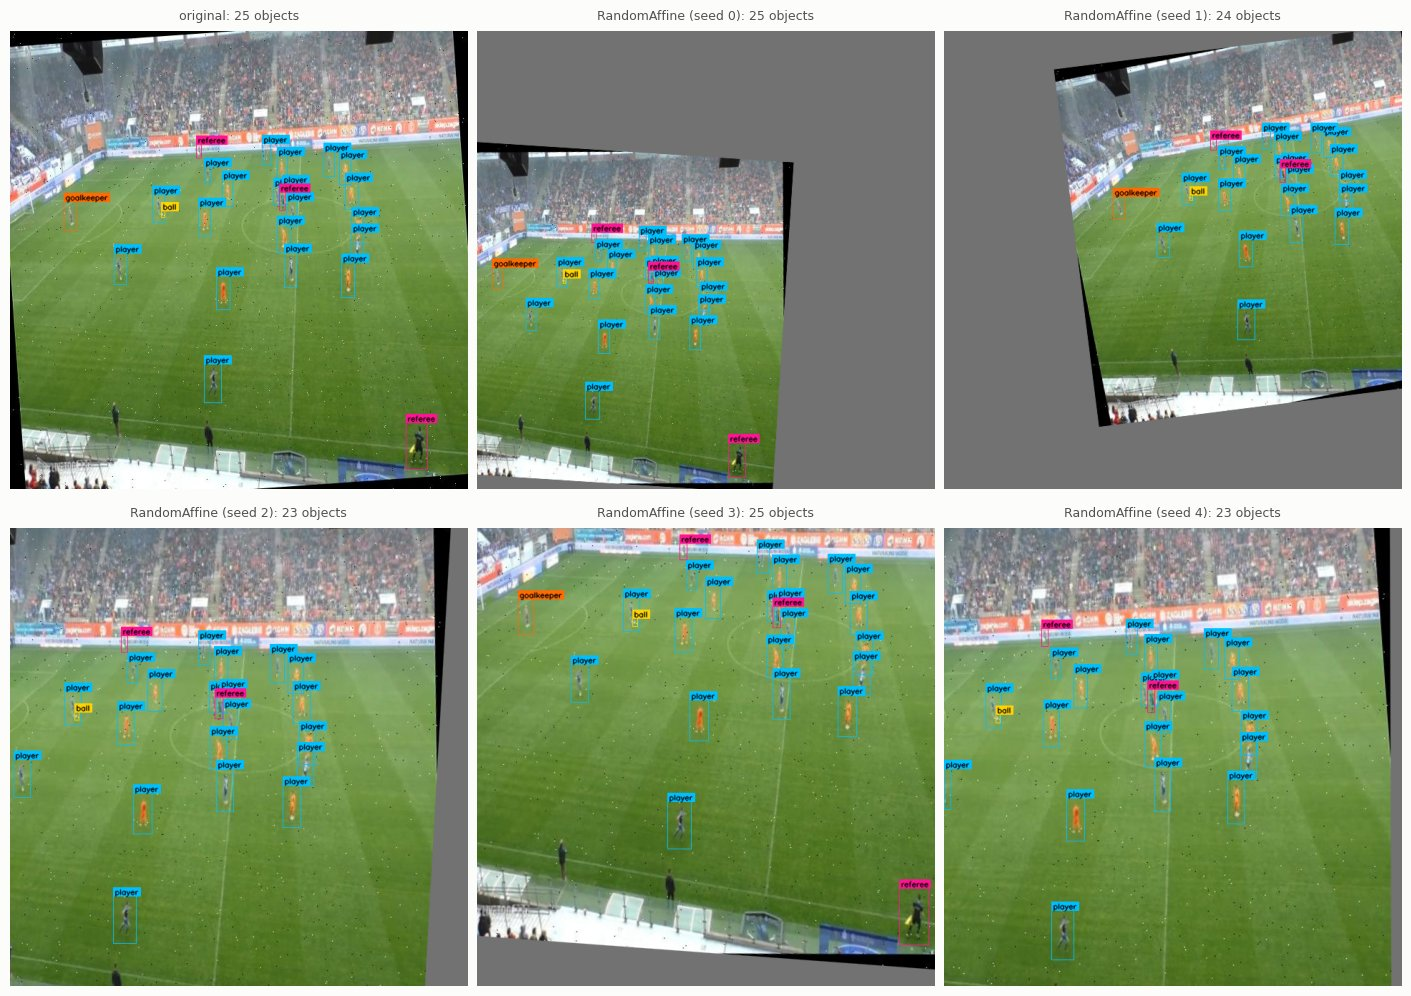

In [4]:
affine = A.RandomAffine(degrees=8, translate=0.2, scale=(0.7, 1.3), p=1.0)
before_after(
    affine, image, labels, detection.class_names, seeds=(0, 1, 2, 3, 4), width=14
)

## Photometric transforms

These change only pixel values: lighting, focus and compression vary between
broadcasts. Blur, noise and JPEG artefacts are small, so the views below are
zoomed in on one player. The annotations come back as the very same object.

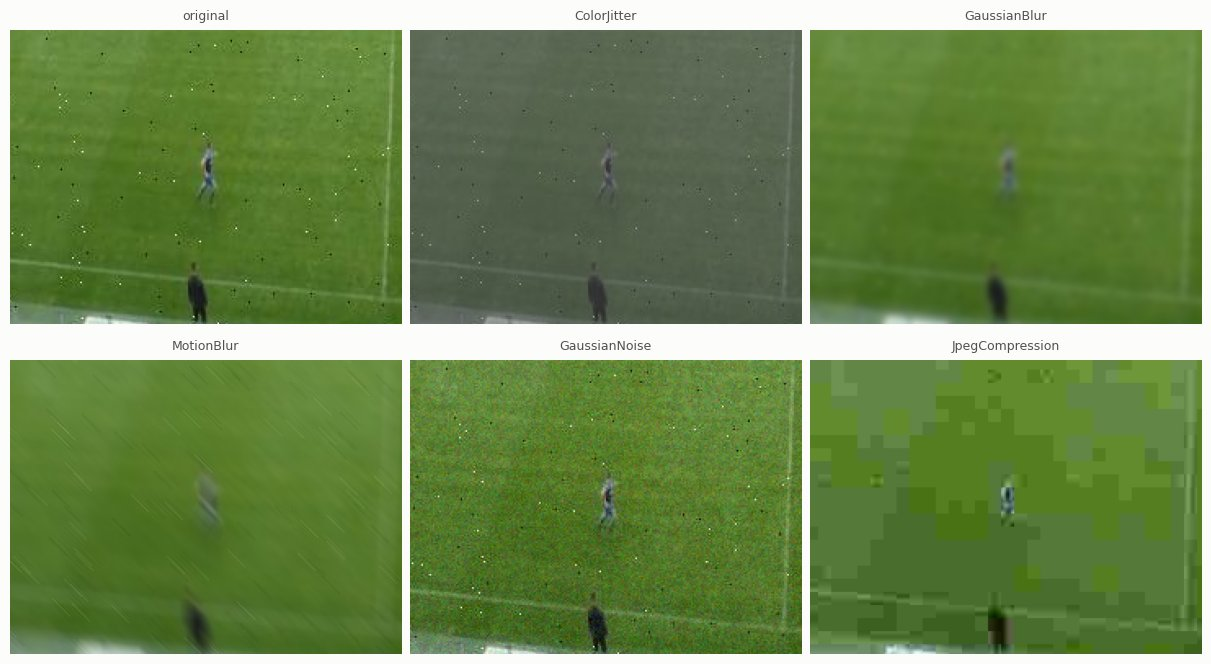

In [5]:
photometric = {
    "ColorJitter": A.ColorJitter(
        brightness=0.4, contrast=0.4, saturation=0.5, hue=0.05, p=1.0
    ),
    "GaussianBlur": A.GaussianBlur(sigma=(2.0, 2.0), p=1.0),
    "MotionBlur": A.MotionBlur(kernel_size=(15, 15), p=1.0),
    "GaussianNoise": A.GaussianNoise(std=(12.0, 12.0), p=1.0),
    "JpegCompression": A.JpegCompression(quality=(8, 8), p=1.0),
}
player = labels.boxes[
    list(labels.class_ids).index(detection.class_names.index("player"))
]
cx, cy = (player[:2] + player[2:]) / 2
x0, y0 = int(max(0, cx - 120)), int(max(0, cy - 90))
zoom = (slice(y0, y0 + 180), slice(x0, x0 + 240))

views, titles = [image[zoom]], ["original"]
for name, transform in photometric.items():
    new_image, new_labels = transform(image, labels, np.random.default_rng(0))
    assert new_labels is labels  # pixels only
    views.append(new_image[zoom])
    titles.append(name)
tv.show(views, titles, cols=3, width=12)

## Combining transforms

`Compose` applies transforms in order, each with its own `p`. `OneOf` picks one
of its transforms at random. A typical training recipe flips half the time,
moves the camera a little, varies the colours, and sometimes adds one kind of
degradation. The repr shows the whole recipe.

In [6]:
recipe = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomAffine(degrees=3, translate=0.05, scale=(0.8, 1.2), p=0.7),
        A.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.3, p=0.8),
        A.OneOf([A.MotionBlur(), A.GaussianBlur(), A.GaussianNoise()], p=0.4),
        A.JpegCompression(p=0.3),
    ]
)
recipe

Compose([
    HorizontalFlip(p=0.5),
    RandomAffine(degrees=3.0, translate=0.05, scale=(0.8, 1.2), min_area_ratio=0.3, border_value=(114, 114, 114), p=0.7),
    ColorJitter(brightness=0.25, contrast=0.25, saturation=0.3, hue=0.02, p=0.8),
    OneOf([
        MotionBlur(kernel_size=(3, 11), p=0.5),
        GaussianBlur(sigma=(0.1, 1.5), p=0.5),
        GaussianNoise(std=(2.0, 8.0), p=0.5),
    ], p=0.4),
    JpegCompression(quality=(40, 90), p=0.3),
], p=1.0)

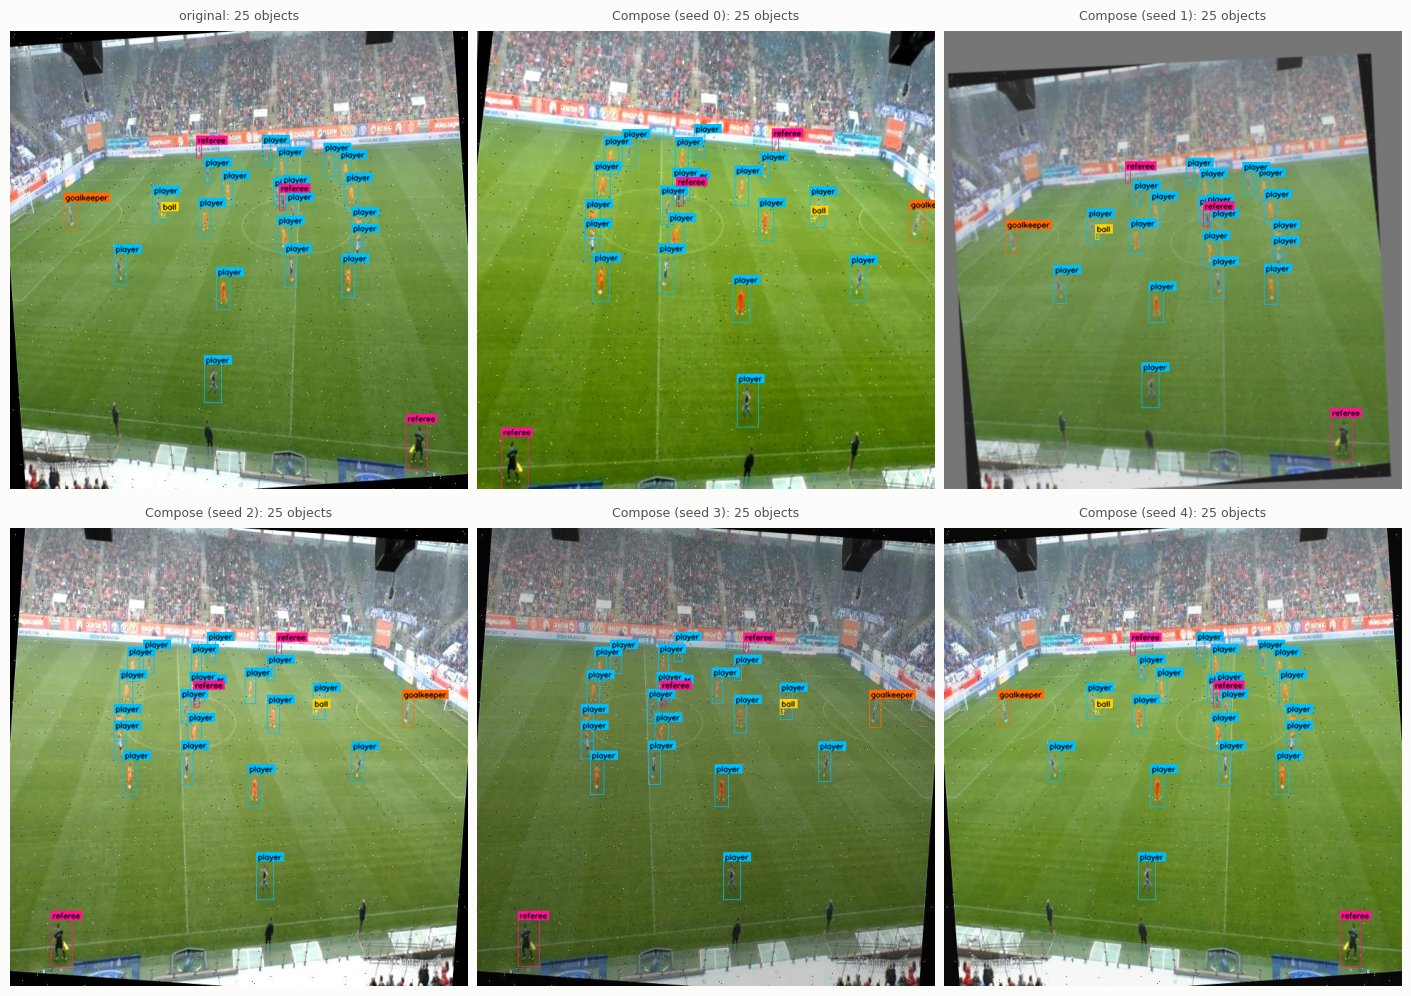

In [7]:
before_after(
    recipe, image, labels, detection.class_names, seeds=(0, 1, 2, 3, 4), width=14
)

## Keypoints under flips and affine transforms

Pitch landmarks have names: keypoint 0 is the corner at one end, keypoint 24
the matching corner at the other end. After a mirror flip, the landmark seen
where keypoint 0 was is really keypoint 24. `HorizontalFlip` renames keypoints
with the dataset's `flip_idx` (new keypoint `i` is the mirrored old keypoint
`flip_idx[i]`); the dataset loads `flip_idx` from `data.yaml`.

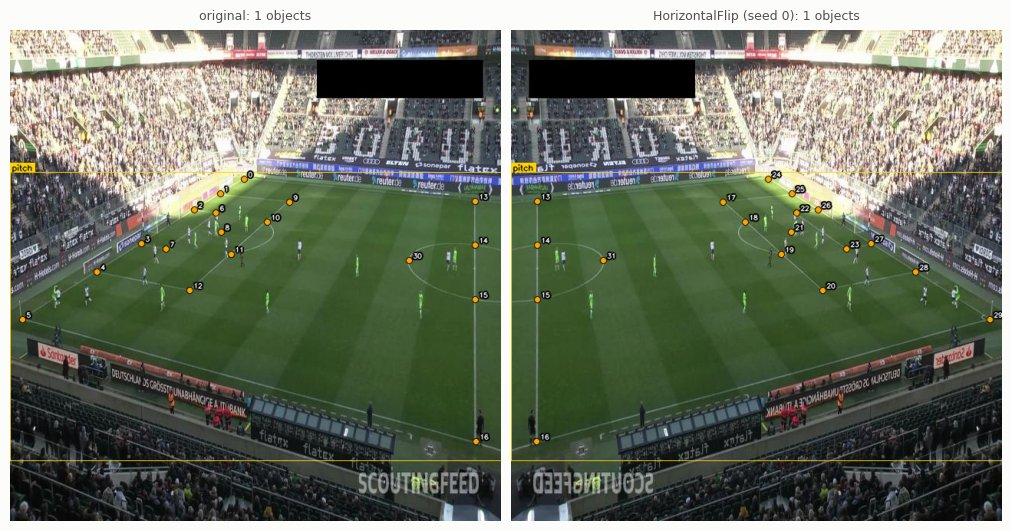

In [8]:
flip = A.HorizontalFlip(p=1.0)
before_after(flip, pitch_image, pitch_labels, pitch_data.class_names, width=10)

The numbers confirm it: each flipped keypoint sits at the mirrored position of
the old keypoint `flip_idx[i]`, and its visibility moves with it.

In [9]:
width = pitch_image.shape[1]
_, flipped = flip(pitch_image, pitch_labels, np.random.default_rng(0))
old, new = pitch_labels.keypoints[0], flipped.keypoints[0]
expected = old[list(pitch_labels.flip_idx)]
print("x mirrored:  ", np.allclose(new[:, 0], width - expected[:, 0]))
print("y unchanged: ", np.allclose(new[:, 1], expected[:, 1]))
print("visibility:  ", np.array_equal(new[:, 2], expected[:, 2]))

x mirrored:   True
y unchanged:  True
visibility:   True


Without `flip_idx` a flip would keep the old names on mirrored positions. The
labels would then describe a mirror image of the pitch, which no camera can
film, and a keypoint model trained on them would learn contradictions.

A homography fitted to the labelled landmarks shows the difference: a real
view preserves the pitch's orientation (the sign of the mapping's Jacobian
determinant), a mirror image reverses it. Annotations without `flip_idx` raise
an error instead of producing such labels silently.

In [10]:
def mirrored(annotations, image_size=640):
    """True when the labelled landmarks only fit a mirror image of the pitch."""
    h = tv.pitch.HomographyEstimator().update(annotations.to_keypoints())
    centre = h[2] @ [image_size / 2, image_size / 2, 1.0]
    return bool(np.linalg.det(h) * centre < 0)


rng = np.random.default_rng(0)
_, renamed = flip(pitch_image, pitch_labels, rng)
_, not_renamed = flip(
    pitch_image, replace(pitch_labels, flip_idx=tuple(range(32))), rng
)
_, moved = A.RandomAffine(degrees=10, translate=0.1, p=1.0)(
    pitch_image, pitch_labels, rng
)
print("original mirrored:              ", mirrored(pitch_labels))
print("flip with flip_idx mirrored:    ", mirrored(renamed))
print("flip keeping old names mirrored:", mirrored(not_renamed))
print("affine mirrored:                ", mirrored(moved))
flagged = [s for s in pitch_data["train"] if mirrored(s.annotations)]
print("training images mirrored:       ", len(flagged), "of", len(pitch_data["train"]))

try:
    flip(pitch_image, replace(pitch_labels, flip_idx=None))
except ValueError as error:
    print("\nwithout flip_idx:", error)

original mirrored:               False
flip with flip_idx mirrored:     False
flip keeping old names mirrored: True
affine mirrored:                 False
training images mirrored:        1 of 255

without flip_idx: HorizontalFlip needs annotations.flip_idx to flip keypoints; set flip_idx in the dataset (e.g. data.yaml) or leave HorizontalFlip out


The same check runs over a whole dataset. The one training image it flags is a
labelling error: its touchline keypoints 13 and 16 are swapped compared with
every other image, so its labels describe a mirrored pitch.

42ba34_9_2_png.rf.fa8be5d9317775bd798a6a84f56f75e4.jpg


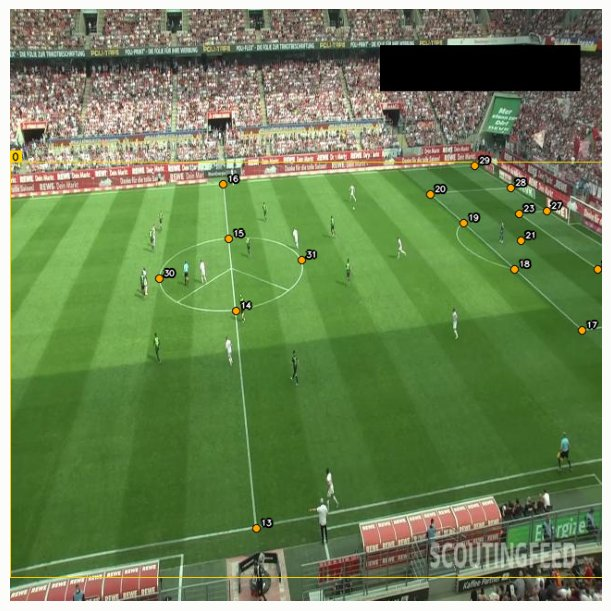

In [11]:
sample = flagged[0]
print(sample.image_path.name)
tv.show(tv.viz.draw_annotations(sample.read_image(), sample.annotations), width=6)

`RandomAffine` moves keypoints with the same matrix as the pixels. Keypoints
that leave the image become "not labelled" (visibility 0) instead of pointing
outside it.

labelled keypoints before: 18  after: 13


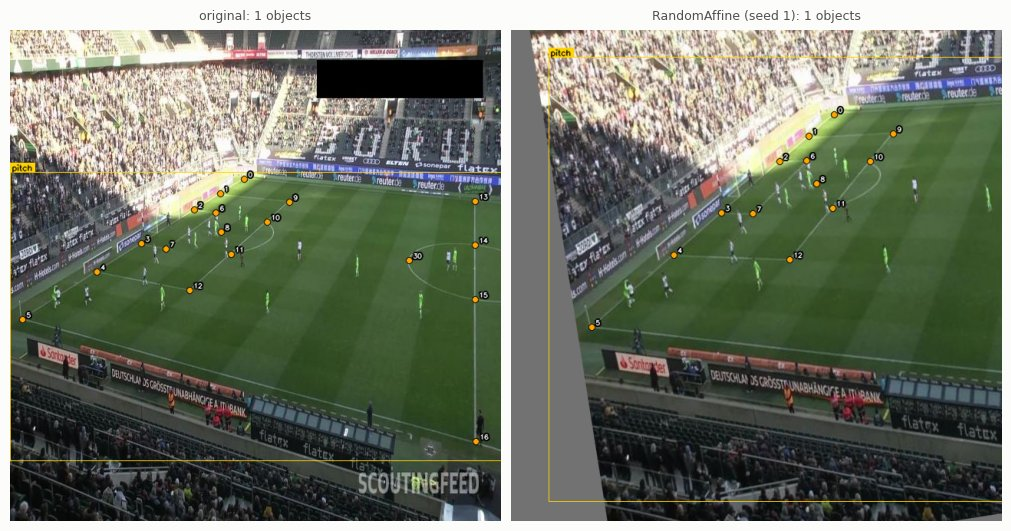

In [12]:
strong = A.RandomAffine(degrees=10, translate=0.25, scale=(1.2, 1.4), p=1.0)
_, zoomed = strong(pitch_image, pitch_labels, np.random.default_rng(1))
print(
    "labelled keypoints before:",
    int((pitch_labels.keypoints[..., 2] > 0).sum()),
    " after:",
    int((zoomed.keypoints[..., 2] > 0).sum()),
)
before_after(
    strong, pitch_image, pitch_labels, pitch_data.class_names, seeds=(1,), width=10
)

## Augmenting a dataset

`show_augmentations` previews a recipe on random dataset images, original and
augmented side by side, before committing to it.

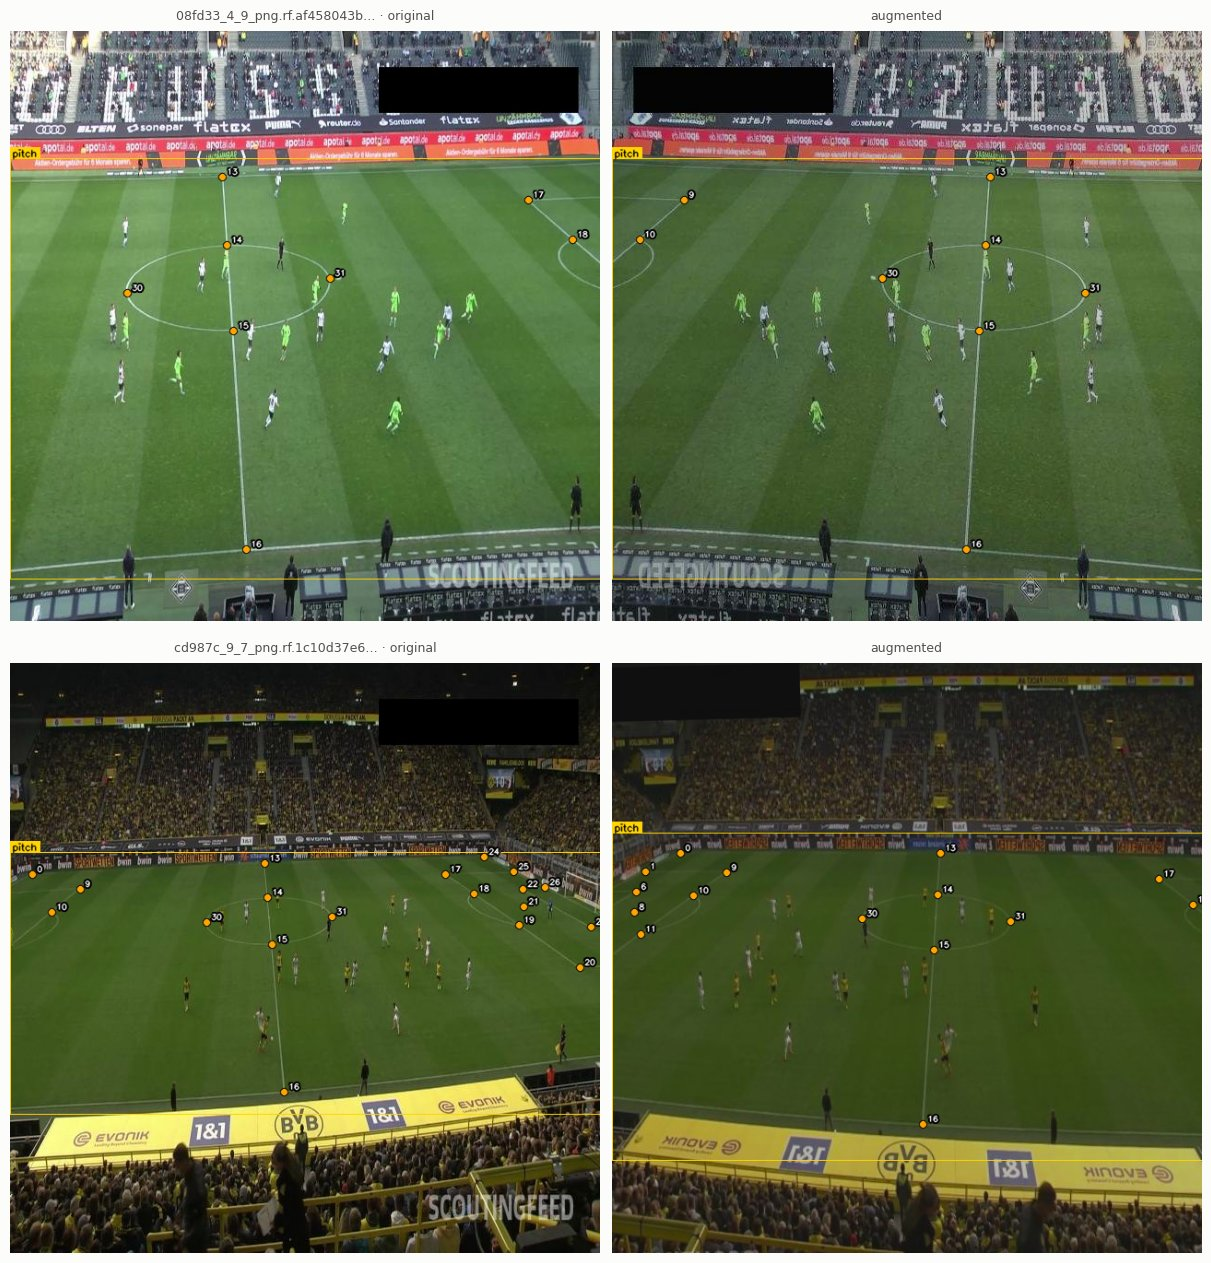

In [13]:
tv.viz.show_augmentations(pitch_data, recipe, n=2, seed=3)

`augment_dataset` writes `copies` augmented variants of every training image
next to the originals and returns the bigger dataset. Validation data is left
alone, so metrics keep measuring performance on real images. The same seed
gives the same images, and the result exports with `to_yolo` / `to_coco` like
any dataset.

It never overwrites: an earlier augmented dataset, and any export of it,
still reads its images, so an image the call would write must not exist yet
(the error names it). Use a new folder per call; this notebook removes its
previous run's folder first.

In [14]:
import shutil

shutil.rmtree(OUT / "augmented", ignore_errors=True)
augmented = A.augment_dataset(
    detection, recipe, OUT / "augmented", copies=2, seed=0, progress=False
)
print(augmented)
augmented.summary()

Dataset(name='football_yolo-aug', task=detect, classes=['ball', 'goalkeeper', 'player', 'referee'], train=180, valid=20)


,images,objects,ball,goalkeeper,player,referee
split,,,,,,
train,180,3698,166,105,3167,260
valid,20,424,19,4,387,14


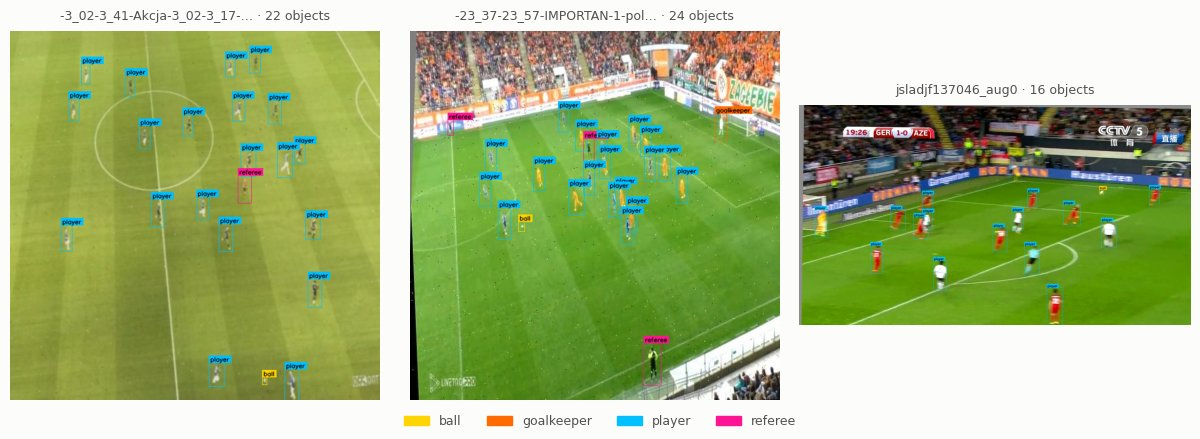

In [15]:
tv.viz.show_samples(
    augmented.with_split("train", augmented["train"][60:]), "train", n=3
)